<a href="https://www.kaggle.com/code/mrafraim/predictive-supply-chain-analytics?scriptVersionId=301801709" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predictive Supply Chain Analytics: Revenue and Risk Forecasting

# 1. Project Overview

### Objective

The objective of this project is to develop a predictive and diagnostic analytical framework for evaluating revenue performance and operational risk within the supply chain of a **Fashion & Beauty startup specializing in makeup products**.

This project focuses on:

* Identifying key drivers of revenue generation across products and SKUs.
* Quantifying operational risks such as high defect rates, extended lead times, and cost volatility.
* Building predictive models to forecast revenue and assess supply chain risk exposure.
* Translating analytical findings into strategic actions for cost optimization and performance stability.

The core business question addressed:

> Which operational factors most strongly influence revenue performance, and how can supply chain risks be predicted and mitigated proactively?

### Domain

Supply Chain Analytics
Industry: Fashion & Beauty (Makeup Products)

### Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Plotly
* Scikit-learn
* SciPy (for statistical validation)


### Dataset Source

[Kaggle - Supply Chain Dataset](https://www.kaggle.com/datasets/harshsingh2209/supply-chain-analysis)

### Dataset Size

Records – 100 | Features – 24


# 2. Data Understanding

## 2.1 Dataset Description

The dataset contains 100 observations of makeup product SKUs. While the sample size is small, the feature density (24 variables) allows for a multidimensional view of the supply chain, covering procurement, production, logistics, and sales.

| Variable | Description |
| --- | --- |
| Product Type | Category of the makeup product (e.g., Skincare, Haircare) |
| SKU | Unique Stock Keeping Unit identifier |
| Price | Sale price of the product | 
| Availability | Current availability status or percentage |
| Number of products sold | Quantity sold to date |
| Revenue generated | Total revenue from the SKU |
| Customer demographics | Target or actual customer segment (e.g., Male, Female, Unknown) |
| Stock levels | Units currently in inventory | 
| Lead times | Time taken from order to delivery |
| Order quantities | Typical quantity per order | 
| Shipping times | Time spent in transit | 
| Shipping carriers | Company responsible for delivery |
| Shipping costs | Expenses related to shipping |
| Supplier name | Name of the raw material or product supplier |
| Location | Geographic origin or warehouse location | 
| Lead time | General procurement lead time | 
| Production volumes | Number of units produced per batch | 
| Manufacturing lead time | Time taken to manufacture the product | 
| Manufacturing costs | Cost incurred during production | 
| Inspection results | Quality control outcome (Pass/Fail/Pending) | 
| Defect rates | Percentage of defective units per batch | 
| Transportation modes | Method of transport (Air, Rail, Road, Sea) | 
| Routes | Logistics path taken |
| Costs | Total operational costs associated |


In [1]:
#Import Necessary Libraries
import pandas as pd # Pandas is used for data manipulation and analysis
import numpy as np # Numpy is used for numerical operations
import matplotlib.pyplot as plt # Matplotlib is used for creating static, animated, and interactive visualizations
import seaborn as sns # Seaborn is used for making statistical graphics
from scipy import stats # Scipy is used for scientific and technical computing

# Warnings is used to manage warning messages
import warnings
warnings.filterwarnings('ignore')

# Plotly is used for interactive visualizations
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# Confirming the imports
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/supply-chain-analysis/supply_chain_data.csv')

# Set option to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataframe
df.head(5)

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

## 2.2 Initial Observations

### 1. Missing Values

In [4]:
# Check for missing values
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

No missing values are present in any of the 24 features. The dataset is complete for all records.

### 2. Duplicate Values

In [5]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

No duplicate records detected. Each row represents a unique SKU and product entry.

### 3. Target Variable Distribution

Since the predictive focus is revenue forecasting, the target variable is Revenue generated (continuous).

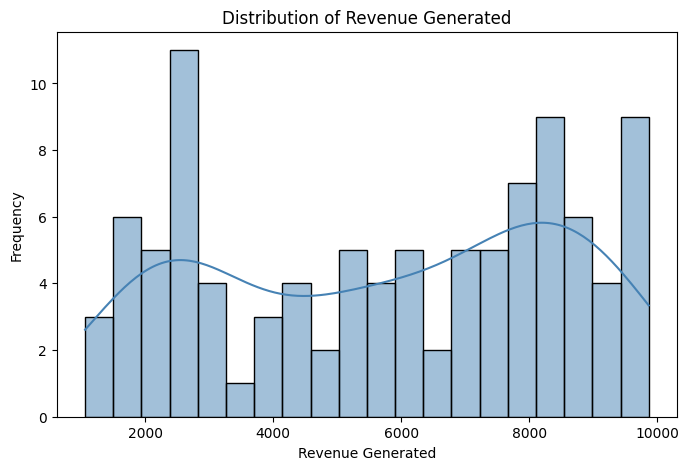

In [6]:
# Check target variable distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Revenue generated'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of Revenue Generated")
plt.xlabel("Revenue Generated")
plt.ylabel("Frequency")
plt.show()

The data follows a bimodal distribution which indicates two main groups: most sales are either small or large. There is a big gap in the middle, meaning customers rarely spend a medium amount.

### 4. Observations & Risk Assessment

A preliminary scan of the data structure reveals several critical points for the upcoming predictive modeling:

* **Data Integrity:** With 100 non-null records across all columns, the dataset is "clean" from a technical standpoint, but the small sample size suggests we should prioritize **Robust Scalers** and potentially **Cross-Validation** to avoid overfitting in the modeling phase.
* **Target Variable Distribution:** "Revenue generated" will serve as our primary continuous target. We will need to check for skewness, as supply chain revenue often follows a power-law distribution (a few SKUs generating most of the value).
* **Operational Constraints:** Variables like `Lead time` and `Manufacturing lead time` are crucial. Discrepancies between these could indicate bottlenecks in the "Procurement vs. Production" phases.
* **Quality Risk:** The `Defect rates` and `Inspection results` provide a supervised label for risk. We will evaluate if high defect rates correlate significantly with specific `Supplier names` or `Transportation modes`.

# 3. Data Preparation

## 3.1 Data Cleaning

Given the high data integrity reported in the technical metadata (zero null values), the cleaning phase focuses on **structural consistency** and **outlier detection**. In a supply chain context, extreme outliers in "Defect Rates" or "Manufacturing Costs" are not always errors; they often represent high-risk events that our predictive model needs to capture or normalize.

* **Handling Missing/Null Values:** Confirmed at 0% across all 24 features.
* **Removing Duplicates:** Verified unique SKUs to ensure no redundant records inflate performance metrics.
* **Addressing Outliers:** Apply the Interquartile Range (IQR) method to identify extreme values in `Revenue generated`, `Manufacturing costs`, `Shipping costs`, and `Price`.


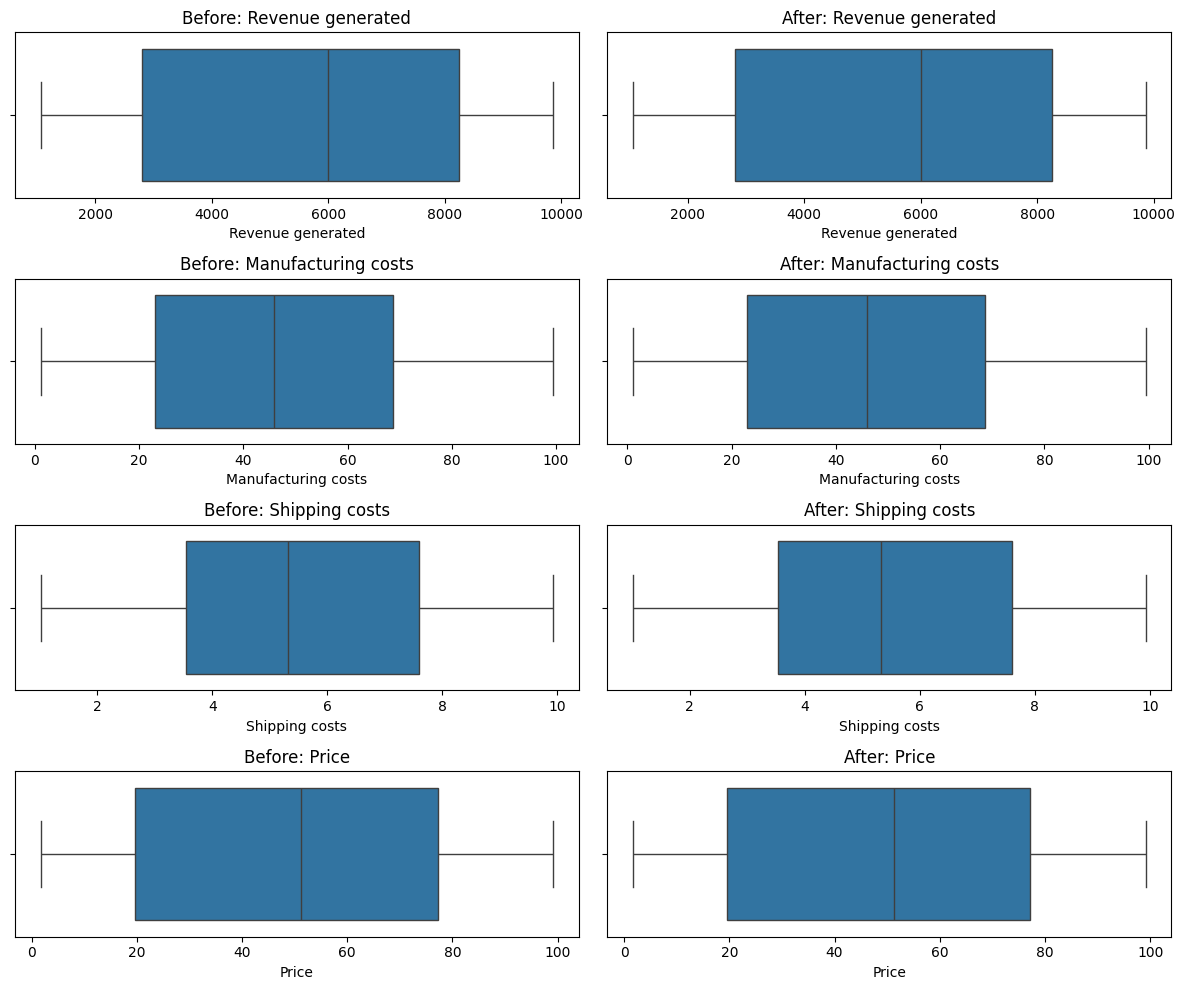

In [7]:
financial_cols = ['Revenue generated', 'Manufacturing costs', 'Shipping costs', 'Price']

df_before = df.copy()

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    return df

# apply outlier handling
for col in financial_cols:
    df = handle_outliers(df, col)

# subplot
fig, axes = plt.subplots(4, 2, figsize=(12,10))

for i, col in enumerate(financial_cols):

    sns.boxplot(x=df_before[col], ax=axes[i,0])
    axes[i,0].set_title(f"Before: {col}")

    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"After: {col}")

plt.tight_layout()
plt.show()

The identical "Before" and "After" boxplots confirm the dataset contains zero statistical outliers in financial features. This lack of noise ensures high data stability for the predictive modeling phase.

## 3.2 Data Transformation

Data transformation converts raw data into a format suitable for statistical modeling and exploratory analysis.

**Type Conversions:**

In [8]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols

(Index(['Product type', 'SKU', 'Customer demographics', 'Shipping carriers',
        'Supplier name', 'Location', 'Inspection results',
        'Transportation modes', 'Routes'],
       dtype='object'),
 Index(['Price', 'Availability', 'Number of products sold', 'Revenue generated',
        'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
        'Shipping costs', 'Lead time', 'Production volumes',
        'Manufacturing lead time', 'Manufacturing costs', 'Defect rates',
        'Costs'],
       dtype='object'))

Verified that all numerical columns are correctly typed as `float64` or `int64` and categorical columns as `object`.

**Unique Values in Categorical Columns:**

In [9]:
df_original = df.copy()

for col in categorical_cols:
    print(f"Column: {col}")
    print(df_original[col].unique())
    print("-" * 100)

Column: Product type
['haircare' 'skincare' 'cosmetics']
----------------------------------------------------------------------------------------------------
Column: SKU
['SKU0' 'SKU1' 'SKU2' 'SKU3' 'SKU4' 'SKU5' 'SKU6' 'SKU7' 'SKU8' 'SKU9'
 'SKU10' 'SKU11' 'SKU12' 'SKU13' 'SKU14' 'SKU15' 'SKU16' 'SKU17' 'SKU18'
 'SKU19' 'SKU20' 'SKU21' 'SKU22' 'SKU23' 'SKU24' 'SKU25' 'SKU26' 'SKU27'
 'SKU28' 'SKU29' 'SKU30' 'SKU31' 'SKU32' 'SKU33' 'SKU34' 'SKU35' 'SKU36'
 'SKU37' 'SKU38' 'SKU39' 'SKU40' 'SKU41' 'SKU42' 'SKU43' 'SKU44' 'SKU45'
 'SKU46' 'SKU47' 'SKU48' 'SKU49' 'SKU50' 'SKU51' 'SKU52' 'SKU53' 'SKU54'
 'SKU55' 'SKU56' 'SKU57' 'SKU58' 'SKU59' 'SKU60' 'SKU61' 'SKU62' 'SKU63'
 'SKU64' 'SKU65' 'SKU66' 'SKU67' 'SKU68' 'SKU69' 'SKU70' 'SKU71' 'SKU72'
 'SKU73' 'SKU74' 'SKU75' 'SKU76' 'SKU77' 'SKU78' 'SKU79' 'SKU80' 'SKU81'
 'SKU82' 'SKU83' 'SKU84' 'SKU85' 'SKU86' 'SKU87' 'SKU88' 'SKU89' 'SKU90'
 'SKU91' 'SKU92' 'SKU93' 'SKU94' 'SKU95' 'SKU96' 'SKU97' 'SKU98' 'SKU99']
----------------------------

**Encoding Categorical Features:**

We have selectively encoded the `Inspection results` feature into an ordinal scale **(Pass=2, Pending=1, Fail=0)**. Unlike nominal categories like "Location," quality inspections have a natural mathematical progression. Encoding this specifically allows us to quantify "Quality Risk" as a numerical variable, which is essential for identifying correlations between manufacturing failures and financial losses. Other nominal features (e.g., Transportation modes) are reserved for one-hot encoding in the modeling phase to avoid "dimensionality explosion" during the EDA process.

In [10]:
# Transform quality results into a 'Risk Score' for mathematical analysis.
inspection_map = {'Pass': 2, 'Pending': 1, 'Fail': 0}
df['Inspection_Score'] = df['Inspection results'].map(inspection_map)

**Data Scaling and Normalization:**

In our dataset, operational metrics are measured in completely different units and sizes. For example, Stock levels typically range from 0 to 100 items, while Revenue generated can easily reach up to $9,000.

If we feed these raw numbers directly into a predictive model, the algorithm will naturally assume that "Revenue" is far more important than "Stock levels" simply because the numbers are physically larger. This is a common pitfall in machine learning known as "unit bias."

To prevent this, we use a technique called Standardization (using StandardScaler). This process mathematically adjusts our numerical columns so they all share the exact same scale specifically, an average value of 0. This "levels the playing field," ensuring that a metric measured in thousands does not overpower a critical metric measured in single digits or percentages.

In [11]:
from sklearn.preprocessing import StandardScaler

# columns to scale
cols = ['Stock levels', 'Order quantities', 'Lead times', 'Revenue generated']

scaler = StandardScaler()

# scale the columns
scaled_values = scaler.fit_transform(df[cols])

# create new columns with "_Scaled"
df[[col + "_Scaled" for col in cols]] = scaled_values

# check result
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Inspection_Score,Stock levels_Scaled,Order quantities_Scaled,Lead times_Scaled,Revenue generated_Scaled
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,1,0.327757,1.755336,-1.024965,1.061345
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,1,0.167563,-0.458534,1.606084,0.619626
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,1,-1.498456,1.455150,-0.681785,1.398125
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,0,-0.793602,0.366977,-0.338605,0.732138
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,0,-1.370301,0.254407,-1.482539,-1.136219


## 3.3 Feature Engineering
Raw data provides snapshots, but feature engineering provides the "efficiency" story. We derive new features to capture the hidden complexities of the supply chain lifecycle.

Logic behind Feature Creation:

- **Net Profit:** Profit after considering costs.
- **Profit Margin**: Revenue alone is a vanity metric; calculating the margin identifies which products are truly profitable after accounting for total costs.
- **Total Cycle Time:** Supply chain risk is cumulative. By summing procurement lead time, manufacturing time, and shipping time, we identify the true "Order-to-Shelf" duration.
- **Risk-Adjusted Cost:** This adds a penalty to manufacturing costs based on the defect rate. A product with a 5% defect rate effectively costs more to bring to market than its base production price suggests.

In [12]:
# Derived Feature: Net Profit
df['Net_Profit'] = df['Revenue generated'] - df['Costs']

# Derived Feature: Profit Margin (%)
df['Profit_Margin'] = (df['Revenue generated'] - df['Costs']) / df['Revenue generated']

# Derived Feature: Total Cycle Time (Order-to-Shelf)
df['Total_Cycle_Time'] = df['Lead time'] + df['Manufacturing lead time'] + df['Shipping times']

# Derived Feature: Risk-Adjusted Manufacturing Cost
df['Risk_Adjusted_Cost'] = df['Manufacturing costs'] * (1 + (df['Defect rates'] / 100))

In [13]:
# Exporting the prepared dataset for the next section
df.to_csv('supply_chain_prepared.csv', index=False)

# 4. Exploratory Data Analysis (EDA)

In this section we will observe the supply chain from the different operational angles. For this purpose, will use both the raw metrics and metrics, we have created using feature engineering.

## 4.1 Financial & Operational Baseline

First, we look at the overall health of our finances and how long it takes to fulfill orders.

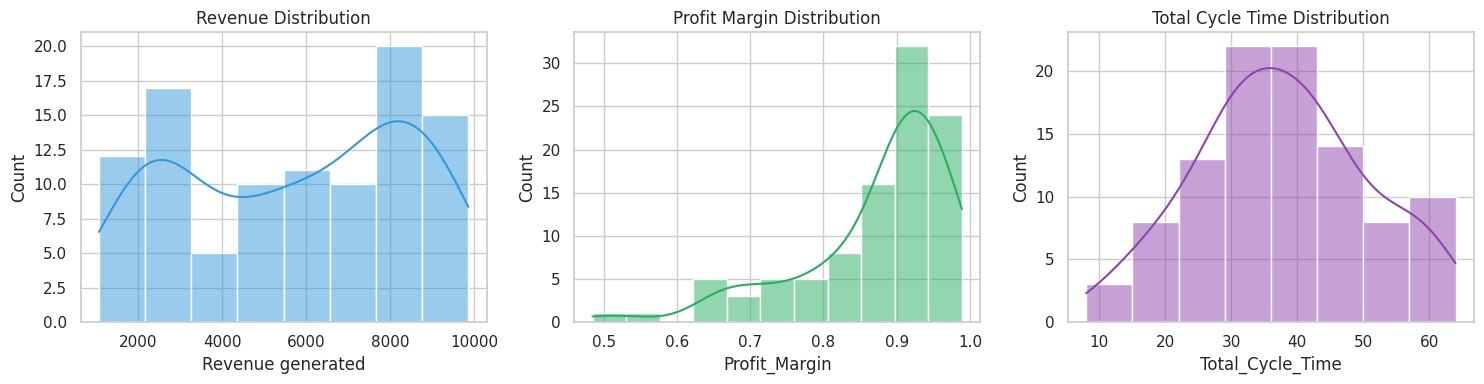

In [14]:
# Set consistent corporate styling
sns.set_theme(style="whitegrid", palette="muted")

# Load data and explicitly define the engineered features from Section 3
df = pd.read_csv('supply_chain_prepared.csv') # Using the prepared dataset

# Financial & Cycle Time Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Revenue generated'], kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Revenue Distribution', fontsize=12)

sns.histplot(df['Profit_Margin'], kde=True, ax=axes[1], color='#27ae60')
axes[1].set_title('Profit Margin Distribution', fontsize=12)

sns.histplot(df['Total_Cycle_Time'], kde=True, ax=axes[2], color='#8e44ad')
axes[2].set_title('Total Cycle Time Distribution', fontsize=12)

plt.tight_layout()
plt.show()

Our products consistently generate strong, predictable profit margins (averaging around 87%). However, the time it takes to get products from order to delivery varies wildly anywhere from 10 to over 60 days. This massive inconsistency in delivery times is our biggest operational bottleneck.

## 4.2 Customer Demographics & Product Strategy

Next, we check who is buying our products to see if our product lines are reaching the right audiences.

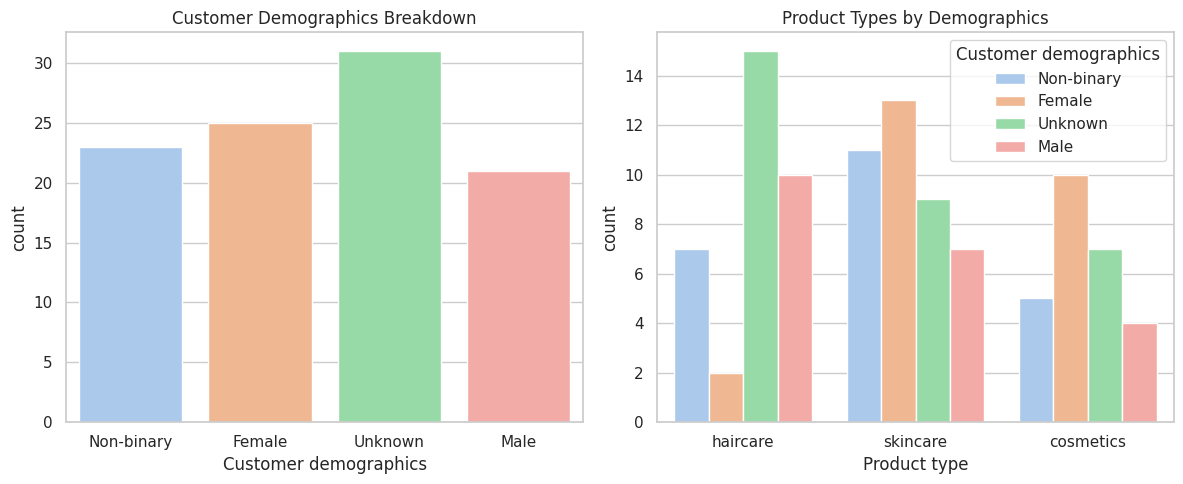

In [15]:
# Demographics & Product Strategy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Customer demographics', palette='pastel', ax=axes[0])
axes[0].set_title('Customer Demographics Breakdown', fontsize=12)

sns.countplot(data=df, x='Product type', hue='Customer demographics', palette='pastel', ax=axes[1])
axes[1].set_title('Product Types by Demographics', fontsize=12)

plt.tight_layout()
plt.show()

The largest demographic group is "Unknown". This indicates a significant gap in data collection during the customer journey. Converting these "Unknowns" into known profiles could unlock highly personalized marketing.

Product Preferences:

- **Skincare:** This is the most popular category for Female and Non-binary customers.
- **Haircare:** This category is dominated by the "Unknown" demographic.
- **Cosmetics:** Shows more balanced engagement but is particularly strong among Female customers.

## 4.3 Profitability Drivers: Volume vs. Time

We want to know if expensive items make us the most money, and if faster delivery times lead to better profit margins.

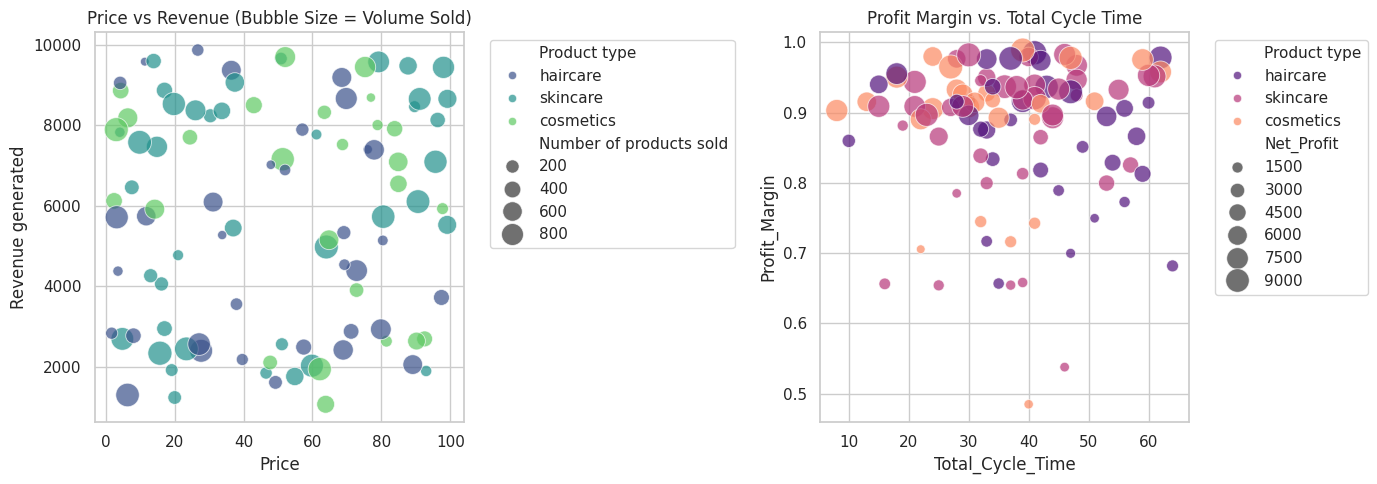

In [16]:
# Profitability Dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price vs Revenue by Volume
sns.scatterplot(data=df, x='Price', y='Revenue generated', hue='Product type', 
                size='Number of products sold', sizes=(40, 300), alpha=0.7, palette='viridis', ax=axes[0])
axes[0].set_title('Price vs Revenue (Bubble Size = Volume Sold)', fontsize=12)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Profit Margin vs Total Cycle Time
sns.scatterplot(data=df, x='Total_Cycle_Time', y='Profit_Margin', hue='Product type', 
                size='Net_Profit', sizes=(40, 300), alpha=0.7, palette='magma', ax=axes[1])
axes[1].set_title('Profit Margin vs. Total Cycle Time', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

High revenue is driven by volume, not just the price tag.If we look at the **Price vs. Revenue chart**, we see that you are hitting peak revenue tiers (8,000 to 10,000) across the entire price spectrum.

Our profit margins are incredibly resilient, regardless of how long fulfillment takes. While faster delivery is always great for customer satisfaction, we don't need to panic or spend heavily to speed up our 50+ unit cycle times just to save our margins. Our current pricing structure perfectly absorbs the cost of those longer operational cycles.


## 4.4 Hidden Risks: Supplier Reliability & Quality Costs
Base manufacturing costs don't tell the whole story. We need to factor in the financial penalty of defective products.

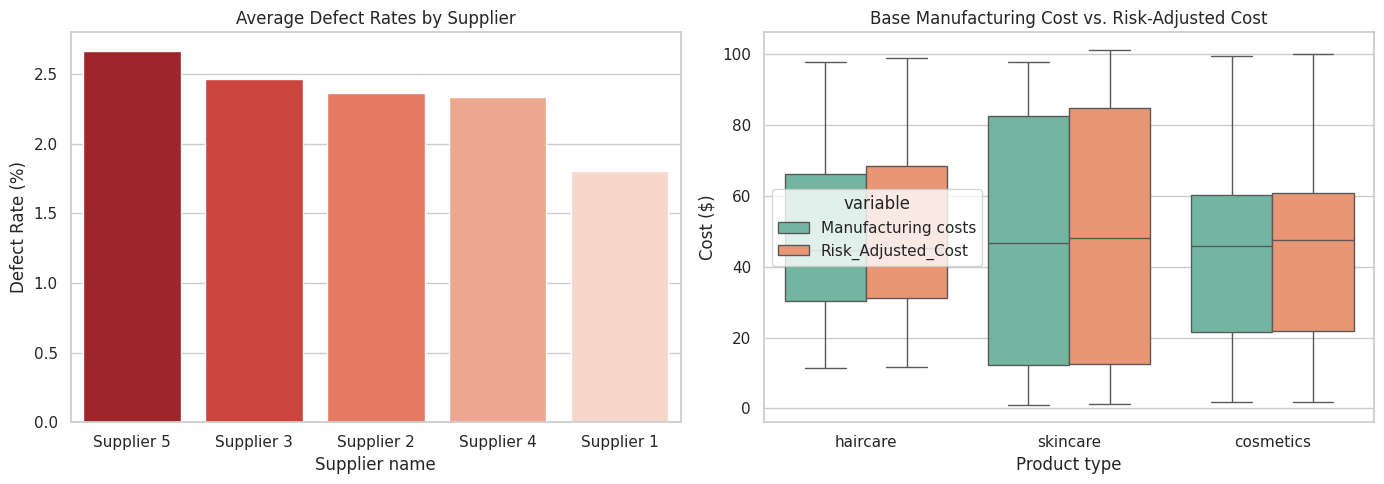

In [17]:
# Risk & Quality Assessment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Supplier Defect Rates
order_sup = df.groupby('Supplier name')['Defect rates'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Supplier name', y='Defect rates', order=order_sup, palette='Reds_r', errorbar=None, ax=axes[0])
axes[0].set_title('Average Defect Rates by Supplier', fontsize=12)
axes[0].set_ylabel('Defect Rate (%)')

# Base vs Risk-Adjusted Cost
df_melted = df[['Product type', 'Manufacturing costs', 'Risk_Adjusted_Cost']].melt(id_vars='Product type')
sns.boxplot(data=df_melted, x='Product type', y='value', hue='variable', palette='Set2', ax=axes[1])
axes[1].set_title('Base Manufacturing Cost vs. Risk-Adjusted Cost', fontsize=12)
axes[1].set_ylabel('Cost ($)')

plt.tight_layout()
plt.show()

Supplier 5 is our most unreliable partner, producing the highest rate of defective items. Also, while Skincare products seem cheap to make on paper, they actually have the highest "hidden costs" when we factor in the money lost to defects. We need to strictly renegotiate quality terms with Supplier 5 and review Skincare manufacturing.

## 4.5 Logistics Bottlenecks & Inspection Delays

We look at which shipping carriers cause delays and how failing a quality inspection impacts the total delivery time.

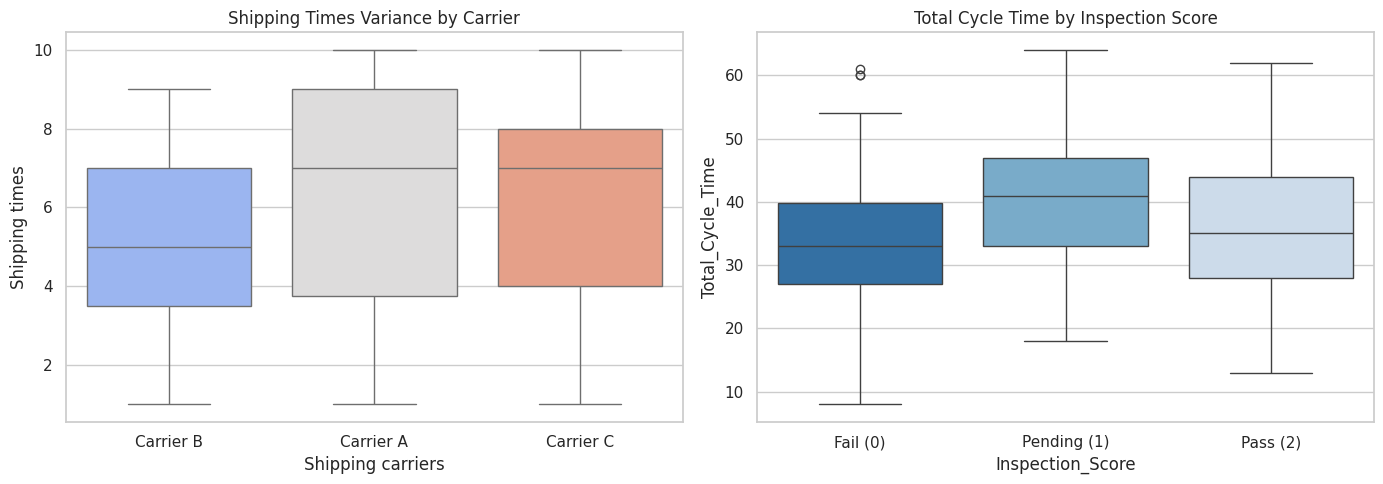

In [18]:
# Logistics & Inspection Impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shipping Times by Carrier
sns.boxplot(data=df, x='Shipping carriers', y='Shipping times', palette='coolwarm', ax=axes[0])
axes[0].set_title('Shipping Times Variance by Carrier', fontsize=12)

# Cycle Time by Inspection Score
sns.boxplot(data=df, x='Inspection_Score', y='Total_Cycle_Time', palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Cycle Time by Inspection Score', fontsize=12)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Fail (0)', 'Pending (1)', 'Pass (2)'])

plt.tight_layout()
plt.show()

Carrier B is noticeably faster and more consistent than the others. It has the lowest median shipping time (around 5 days/units) and the tightest "box" (Interquartile Range), meaning fewer unexpected delays. If the goal is to tighten overall cycle times and improve customer satisfaction, shifting more order volume to Carrier B is an immediate operational win.

Items with a "Pending (1)" inspection score have the highest median total cycle time (over 40 units). This indicates that when items are held up in review or awaiting a decision, they significantly drag down the overall operational efficiency. The primary bottleneck in our cycle time is indecision. Streamlining the inspection process to quickly move items out of the "Pending" purgatory will noticeably bring down our average cycle times.

## 4.6 Feature Relationships (Correlation Map)

Finally, we check if spending more money in certain areas naturally fixes problems in other areas

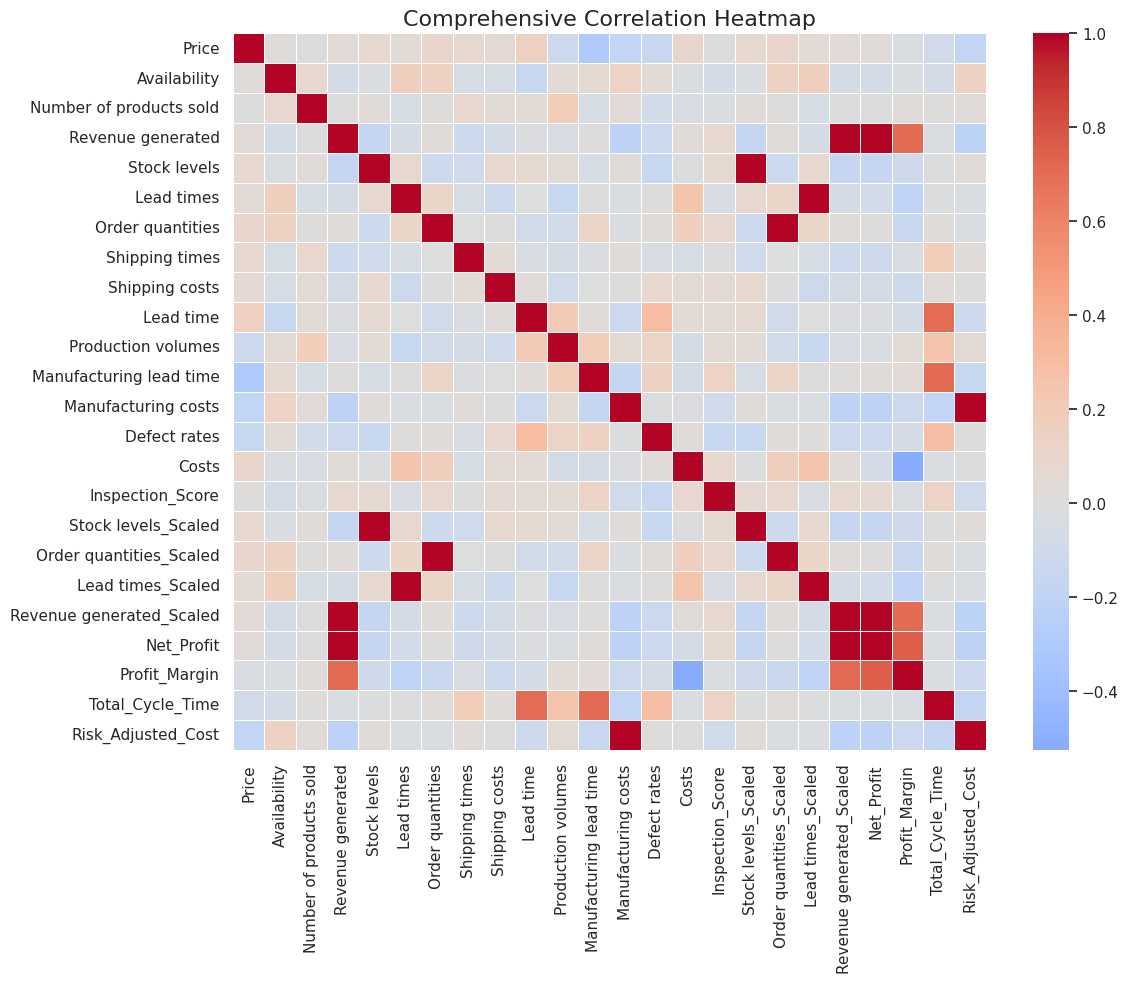

In [19]:
# Comprehensive Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Comprehensive Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

Spending more money on manufacturing does not guarantee better quality or fewer defects (there is no strong link between cost and defect rates). This means we cannot just "buy" our way out of supply chain issues; we have to fix the actual operational processes.

# 5. Statistical & Diagnostic Analysis

While Exploratory Data Analysis (EDA) highlights visual trends and potential operational bottlenecks, it is critical to rigorously test whether these observed patterns are mathematically significant or merely the result of random variance within our 100-SKU sample size. This diagnostic section assesses data readiness for predictive modeling and provides a statistically backed reality check on our operational assumptions.

<p style="text-align:center; color:Red; font-size:18px;">TO BE CONTINUE...</p>

---

<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
